<div style="
background: linear-gradient(90deg, #82065f, #f317ca);
padding: 25px;
border-radius: 10px;
text-align: center;
color: white;
font-family: Arial;
">

<h1 style="margin-bottom:5px;">Employee Turnover Prediction</h1>

<h3 style="margin-top:0;">
Identifying Employees at Risk of Leaving the Company
</h3>

<p>
Hackathon Project • HR Analytics • Explainable AI
</p>

</div>

# Employee Turnover Prediction

The goal of this project is to predict voluntary employee turnover.
The analysis will help HR identify employees at risk of leaving the company
and understand the factors contributing to their departure.

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Load the dataset and display basic information

In [19]:
df = pd.read_csv("../data/HRDataset_v14.csv")
df.head()

,Employee_Name,EmpID,MarriedID,MaritalStatusID,GenderID,EmpStatusID,DeptID,PerfScoreID,FromDiversityJobFairID,Salary,...,ManagerName,ManagerID,RecruitmentSource,PerformanceScore,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,LastPerformanceReview_Date,DaysLateLast30,Absences
0,"Adinolfi, Wilson K",10026,0,0,1,1,5,4,0,62506,...,Michael Albert,22.0,LinkedIn,Exceeds,4.60,5,0,1/17/2019,0,1
1,"Ait Sidi, Karthikeyan",10084,1,1,1,5,3,3,0,104437,...,Simon Roup,4.0,Indeed,Fully Meets,4.96,3,6,2/24/2016,0,17
2,"Akinkuolie, Sarah",10196,1,1,0,5,5,3,0,64955,...,Kissy Sullivan,20.0,LinkedIn,Fully Meets,3.02,3,0,5/15/2012,0,3
3,"Alagbe,Trina",10088,1,1,0,1,5,3,0,64991,...,Elijiah Gray,16.0,Indeed,Fully Meets,4.84,5,0,1/3/2019,0,15
4,"Anderson, Carol",10069,0,2,0,5,5,3,0,50825,...,Webster Butler,39.0,Google Search,Fully Meets,5.00,4,0,2/1/2016,0,2


In [20]:
# Display the shape of the dataset
print("Shape du dataset :", df.shape)

Shape du dataset : (311, 36)


In [21]:
# Display columns and types 
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 311 entries, 0 to 310
Data columns (total 36 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Employee_Name               311 non-null    str    
 1   EmpID                       311 non-null    int64  
 2   MarriedID                   311 non-null    int64  
 3   MaritalStatusID             311 non-null    int64  
 4   GenderID                    311 non-null    int64  
 5   EmpStatusID                 311 non-null    int64  
 6   DeptID                      311 non-null    int64  
 7   PerfScoreID                 311 non-null    int64  
 8   FromDiversityJobFairID      311 non-null    int64  
 9   Salary                      311 non-null    int64  
 10  Termd                       311 non-null    int64  
 11  PositionID                  311 non-null    int64  
 12  Position                    311 non-null    str    
 13  State                       311 non-null    st

In [22]:
# Display all the columns
df.columns

Index(['Employee_Name', 'EmpID', 'MarriedID', 'MaritalStatusID', 'GenderID',
       'EmpStatusID', 'DeptID', 'PerfScoreID', 'FromDiversityJobFairID',
       'Salary', 'Termd', 'PositionID', 'Position', 'State', 'Zip', 'DOB',
       'Sex', 'MaritalDesc', 'CitizenDesc', 'HispanicLatino', 'RaceDesc',
       'DateofHire', 'DateofTermination', 'TermReason', 'EmploymentStatus',
       'Department', 'ManagerName', 'ManagerID', 'RecruitmentSource',
       'PerformanceScore', 'EngagementSurvey', 'EmpSatisfaction',
       'SpecialProjectsCount', 'LastPerformanceReview_Date', 'DaysLateLast30',
       'Absences'],
      dtype='str')

In [23]:
# statistical infomation
df.describe()

,EmpID,MarriedID,MaritalStatusID,GenderID,EmpStatusID,DeptID,PerfScoreID,FromDiversityJobFairID,Salary,Termd,PositionID,Zip,ManagerID,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,DaysLateLast30,Absences
count,311.000000,311.000000,311.000000,311.000000,311.000000,311.000000,311.000000,311.000000,311.000000,311.000000,311.000000,311.000000,303.000000,311.000000,311.000000,311.000000,311.000000,311.000000
mean,10156.000000,0.398714,0.810289,0.434084,2.392283,4.610932,2.977492,0.093248,69020.684887,0.334405,16.845659,6555.482315,14.570957,4.110000,3.890675,1.218650,0.414791,10.237942
std,89.922189,0.490423,0.943239,0.496435,1.794383,1.083487,0.587072,0.291248,25156.636930,0.472542,6.223419,16908.396884,8.078306,0.789938,0.909241,2.349421,1.294519,5.852596
min,10001.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,45046.000000,0.000000,1.000000,1013.000000,1.000000,1.120000,1.000000,0.000000,0.000000,1.000000
25%,10078.500000,0.000000,0.000000,0.000000,1.000000,5.000000,3.000000,0.000000,55501.500000,0.000000,18.000000,1901.500000,10.000000,3.690000,3.000000,0.000000,0.000000,5.000000
50%,10156.000000,0.000000,1.000000,0.000000,1.000000,5.000000,3.000000,0.000000,62810.000000,0.000000,19.000000,2132.000000,15.000000,4.280000,4.000000,0.000000,0.000000,10.000000
75%,10233.500000,1.000000,1.000000,1.000000,5.000000,5.000000,3.000000,0.000000,72036.000000,1.000000,20.000000,2355.000000,19.000000,4.700000,5.000000,0.000000,0.000000,15.000000
max,10311.000000,1.000000,4.000000,1.000000,5.000000,6.000000,4.000000,1.000000,250000.000000,1.000000,30.000000,98052.000000,39.000000,5.000000,5.000000,8.000000,6.000000,20.000000


In [24]:
# Display the missing values 
missing_values = df.isnull().sum().sort_values(ascending=False)
print(missing_values)

DateofTermination             207
ManagerID                       8
Employee_Name                   0
EmpID                           0
MaritalStatusID                 0
MarriedID                       0
GenderID                        0
EmpStatusID                     0
FromDiversityJobFairID          0
Salary                          0
DeptID                          0
PerfScoreID                     0
Position                        0
State                           0
Zip                             0
DOB                             0
Sex                             0
MaritalDesc                     0
Termd                           0
PositionID                      0
HispanicLatino                  0
CitizenDesc                     0
DateofHire                      0
RaceDesc                        0
TermReason                      0
EmploymentStatus                0
Department                      0
ManagerName                     0
RecruitmentSource               0
PerformanceSco

Distribution of the target variable:
Termd
0    207
1    104
Name: count, dtype: int64

Distribution in pourcentage:
Termd
0    66.559486
1    33.440514
Name: proportion, dtype: float64


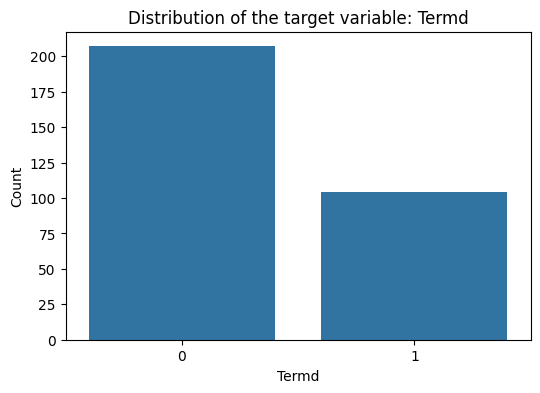

In [25]:
#Distribution of the target variable
target = "Termd"

# Comptage des classes
print("Distribution of the target variable:")
print(df[target].value_counts())
    
print("\nDistribution in pourcentage:")
print(df[target].value_counts(normalize=True) * 100)
    
# Visualisation
plt.figure(figsize=(6,4))
sns.countplot(x=target, data=df)
plt.title(f"Distribution of the target variable: {target}")
plt.xlabel(target)
plt.ylabel("Count")
    
plt.show()


The target variable represents voluntary employee turnover.

0 = employee still active  
1 = employee left the company voluntarily

In [26]:
# Display the reasons of the departure 
df["TermReason"].value_counts()

TermReason
N/A-StillEmployed                   207
Another position                     20
unhappy                              14
more money                           11
career change                         9
hours                                 8
attendance                            7
return to school                      5
relocation out of area                5
performance                           4
retiring                              4
military                              4
no-call, no-show                      4
maternity leave - did not return      3
medical issues                        3
Learned that he is a gangster         1
Fatal attraction                      1
gross misconduct                      1
Name: count, dtype: int64

The dataset contains employee demographic information,
performance indicators and employment history.

### Filtering the dataset

To focus on voluntary employee turnover, we remove cases where employees
were terminated by the.

In [27]:
#filtrage 
voluntary_reasons = [
    "Another position",
    "unhappy",
    "more money",
    "career change",
    "hours",
    "return to school",
    "relocation out of area",
    "maternity leave - did not return",
    "retiring",
    "military",
    "medical issues"
]

df_filtered = df[
    (df["TermReason"] == "N/A-StillEmployed") |
    (df["TermReason"].isin(voluntary_reasons))
]

In [28]:
print("Initial number :", len(df))
print("After filtering :", len(df_filtered))

Initial number : 311
After filtering : 293


In [29]:
#verifications of the reasons we decided to keep
df_filtered["TermReason"].value_counts()

TermReason
N/A-StillEmployed                   207
Another position                     20
unhappy                              14
more money                           11
career change                         9
hours                                 8
return to school                      5
relocation out of area                5
retiring                              4
military                              4
maternity leave - did not return      3
medical issues                        3
Name: count, dtype: int64